<a href="https://colab.research.google.com/github/akshas-25/6th-Sem-ML-Lab/blob/main/LogisticRegression_Binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("HR_comma_sep.csv")

In [3]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [4]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [6]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


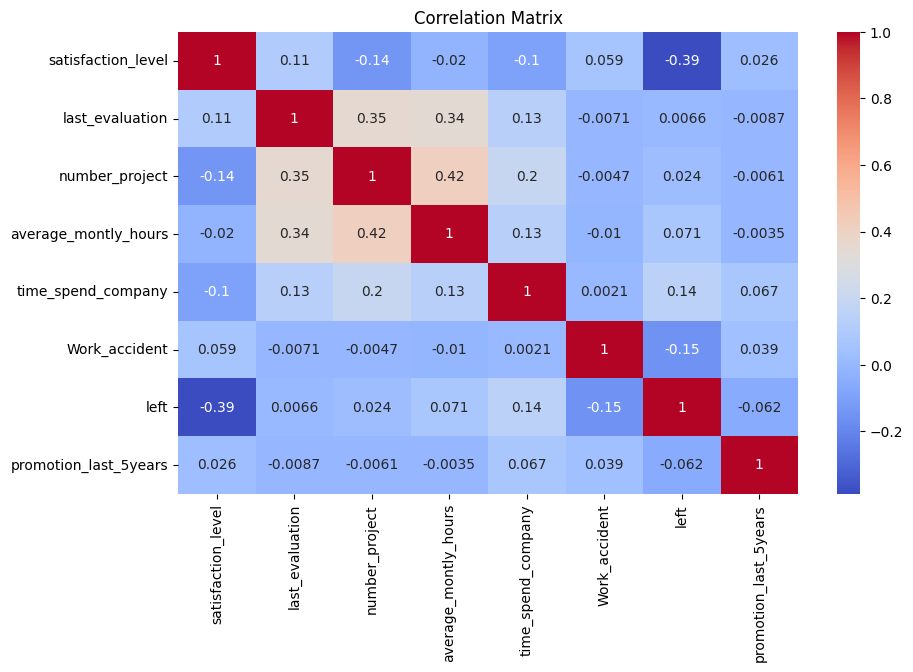


Average values grouped by retention (0=Stayed, 1=Left):
      satisfaction_level  last_evaluation  number_project  \
left                                                        
0               0.666810         0.715473        3.786664   
1               0.440098         0.718113        3.855503   

      average_montly_hours  time_spend_company  Work_accident  \
left                                                            
0               199.060203            3.380032       0.175009   
1               207.419210            3.876505       0.047326   

      promotion_last_5years  
left                         
0                  0.026251  
1                  0.005321  


In [9]:
# Check correlation matrix (numerical variables only)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Average values grouped by retention
retention_group = df.groupby("left").mean(numeric_only=True)
print("\nAverage values grouped by retention (0=Stayed, 1=Left):")
print(retention_group)

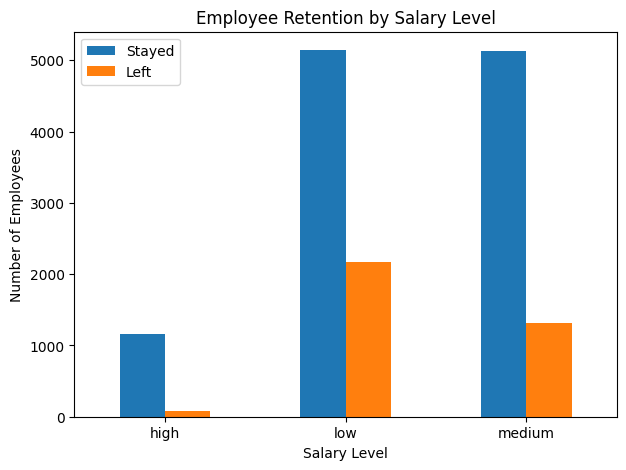

In [10]:
salary_retention = pd.crosstab(df.salary, df.left)

salary_retention.plot(kind='bar', figsize=(7,5))
plt.title("Employee Retention by Salary Level")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Left"])
plt.show()

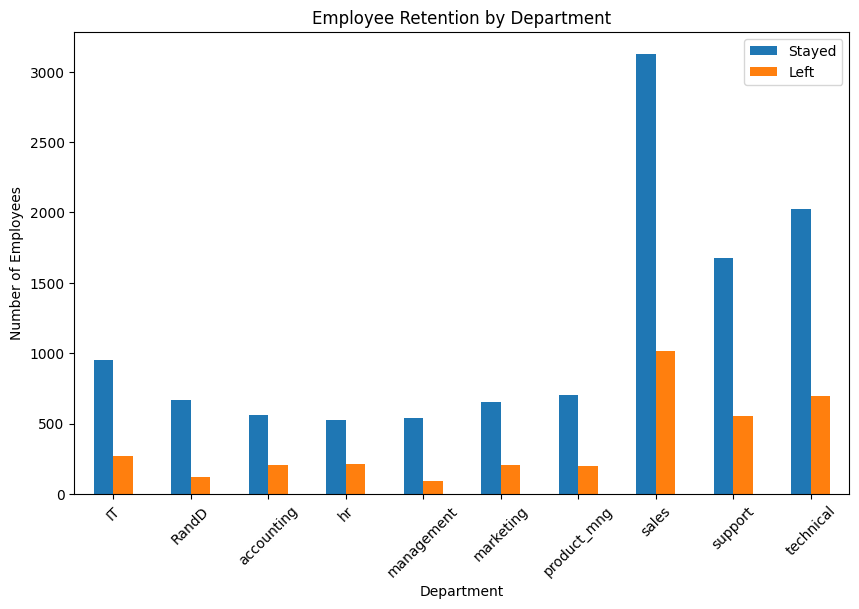

In [11]:
dept_retention = pd.crosstab(df.Department, df.left)

dept_retention.plot(kind='bar', figsize=(10,6))
plt.title("Employee Retention by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.legend(["Stayed", "Left"])
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Convert categorical salary variable to dummy variables
salary_dummies = pd.get_dummies(df.salary, drop_first=True)

# Select features
X = df[['satisfaction_level', 'average_montly_hours',
        'time_spend_company', 'promotion_last_5years']]

X = pd.concat([X, salary_dummies], axis=1)

y = df.left

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# -----------------------------
# STEP 5: Model Evaluation
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.7566666666666667

Confusion Matrix:
[[2100  194]
 [ 536  170]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      2294
           1       0.47      0.24      0.32       706

    accuracy                           0.76      3000
   macro avg       0.63      0.58      0.58      3000
weighted avg       0.72      0.76      0.73      3000



Iteration 0, Cost: 0.6920895151672574
Iteration 100, Cost: 0.6096327308650809
Iteration 200, Cost: 0.5595034735173257
Iteration 300, Cost: 0.5278702326063631
Iteration 400, Cost: 0.5071053626173632
Iteration 500, Cost: 0.49298486169954087
Iteration 600, Cost: 0.48309002772082066
Iteration 700, Cost: 0.47597950864009414
Iteration 800, Cost: 0.4707607457733366
Iteration 900, Cost: 0.46686157619584756
Iteration 1000, Cost: 0.46390389613632166
Iteration 1100, Cost: 0.4616311144210447
Iteration 1200, Cost: 0.45986501211047476
Iteration 1300, Cost: 0.4584792615051207
Iteration 1400, Cost: 0.4573827010647332
Iteration 1500, Cost: 0.4565084987192384
Iteration 1600, Cost: 0.4558069677577705
Iteration 1700, Cost: 0.45524070508609776
Iteration 1800, Cost: 0.45478123945047977
Iteration 1900, Cost: 0.4544066815123363

Model Accuracy: 0.7722514834322288


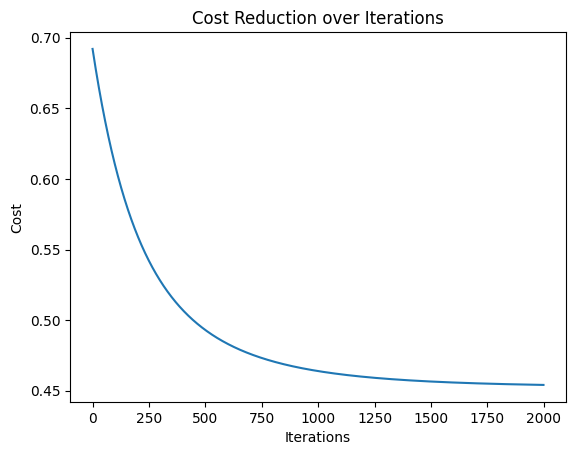

In [14]:


# -----------------------------
# Feature Selection (Based on EDA insight)
# -----------------------------
# Using important variables:
# satisfaction_level, average_montly_hours,
# time_spend_company, promotion_last_5years, salary

# Convert salary to numeric manually
df['salary'] = df['salary'].map({'low':0, 'medium':1, 'high':2})

# Select features
X = df[['satisfaction_level',
        'average_montly_hours',
        'time_spend_company',
        'promotion_last_5years',
        'salary']].values

y = df['left'].values

# -----------------------------
# Feature Scaling (Important for gradient descent)
# -----------------------------
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Add bias term (column of 1s)
m = X.shape[0]
X = np.hstack((np.ones((m,1)), X))

# -----------------------------
# Logistic Regression From Scratch
# -----------------------------

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Cost function
def compute_cost(X, y, weights):
    m = len(y)
    h = sigmoid(X @ weights)
    cost = (-1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost

# Gradient Descent
def gradient_descent(X, y, weights, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        h = sigmoid(X @ weights)
        gradient = (1/m) * (X.T @ (h - y))
        weights = weights - learning_rate * gradient

        cost = compute_cost(X, y, weights)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return weights, cost_history

# Initialize weights
weights = np.zeros(X.shape[1])

# Train model
learning_rate = 0.01
iterations = 2000

weights, cost_history = gradient_descent(X, y, weights, learning_rate, iterations)

# -----------------------------
# Predictions
# -----------------------------
def predict(X, weights):
    probabilities = sigmoid(X @ weights)
    return [1 if i >= 0.5 else 0 for i in probabilities]

y_pred = predict(X, weights)

# -----------------------------
# Accuracy Calculation
# -----------------------------
accuracy = np.mean(y_pred == y)
print("\nModel Accuracy:", accuracy)

# -----------------------------
# Plot Cost Reduction
# -----------------------------
plt.plot(cost_history)
plt.title("Cost Reduction over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()